In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("Product-Sales-Region.xlsx")

df.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [6]:
df.shape

(1500, 19)

In [7]:
df.columns

Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName',
       'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1130 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

In [9]:
df.describe()

,Date,Quantity,UnitPrice,Discount,TotalPrice,Returned,ShippingCost,OrderDate,DeliveryDate
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500
mean,2024-04-07 21:35:02.400000256,10.410667,298.826947,0.073133,2919.994952,0.248000,27.507293,2024-04-07 21:35:02.400000256,2024-04-13 22:36:28.799999744
min,2023-01-01 00:00:00,1.000000,5.520000,0.000000,6.970000,0.000000,5.010000,2023-01-01 00:00:00,2023-01-08 00:00:00
25%,2023-08-20 00:00:00,5.000000,151.020000,0.000000,867.136250,0.000000,16.700000,2023-08-20 00:00:00,2023-08-25 12:00:00
50%,2024-04-08 12:00:00,11.000000,294.740000,0.050000,2174.724000,0.000000,27.100000,2024-04-08 12:00:00,2024-04-15 12:00:00
75%,2024-12-07 06:00:00,15.000000,446.702500,0.100000,4414.723500,0.000000,38.635000,2024-12-07 06:00:00,2024-12-13 06:00:00
max,2025-06-30 00:00:00,20.000000,599.720000,0.150000,11077.000000,1.000000,49.980000,2025-06-30 00:00:00,2025-07-10 00:00:00
std,NaN,5.735732,169.100075,0.055979,2522.789977,0.431996,13.093453,NaN,NaN


In [10]:
df.isnull().sum()

Date               0
Region             0
Product            0
Quantity           0
UnitPrice          0
StoreLocation      0
CustomerType       0
Discount           0
Salesperson        0
TotalPrice         0
PaymentMethod      0
Promotion        370
Returned           0
OrderID            0
CustomerName       0
ShippingCost       0
OrderDate          0
DeliveryDate       0
RegionManager      0
dtype: int64

In [11]:
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_percent)

Date              0.000000
Region            0.000000
Product           0.000000
Quantity          0.000000
UnitPrice         0.000000
StoreLocation     0.000000
CustomerType      0.000000
Discount          0.000000
Salesperson       0.000000
TotalPrice        0.000000
PaymentMethod     0.000000
Promotion        24.666667
Returned          0.000000
OrderID           0.000000
CustomerName      0.000000
ShippingCost      0.000000
OrderDate         0.000000
DeliveryDate      0.000000
RegionManager     0.000000
dtype: float64


In [12]:
df["Promotion"].fillna(
    df["Promotion"].mode()[0],
    inplace=True
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_35364\3009144509.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Promotion"].fillna(


In [13]:
df.isnull().sum()

Date             0
Region           0
Product          0
Quantity         0
UnitPrice        0
StoreLocation    0
CustomerType     0
Discount         0
Salesperson      0
TotalPrice       0
PaymentMethod    0
Promotion        0
Returned         0
OrderID          0
CustomerName     0
ShippingCost     0
OrderDate        0
DeliveryDate     0
RegionManager    0
dtype: int64

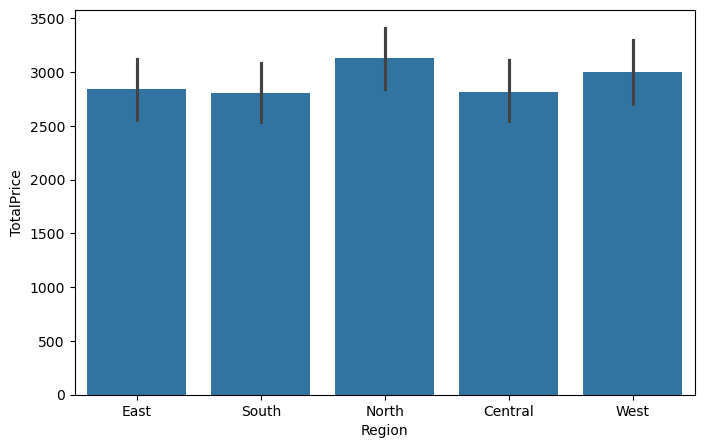

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Region",
    y="TotalPrice",
    data=df
)

plt.show()

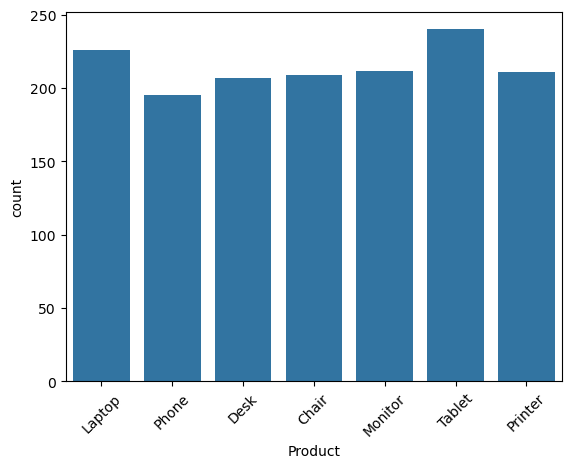

In [15]:
sns.countplot(
    x="Product",
    data=df
)

plt.xticks(rotation=45)

plt.show()

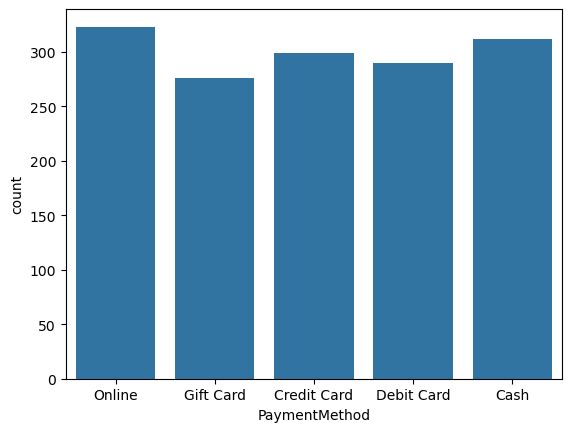

In [16]:
sns.countplot(
    x="PaymentMethod",
    data=df
)

plt.show()

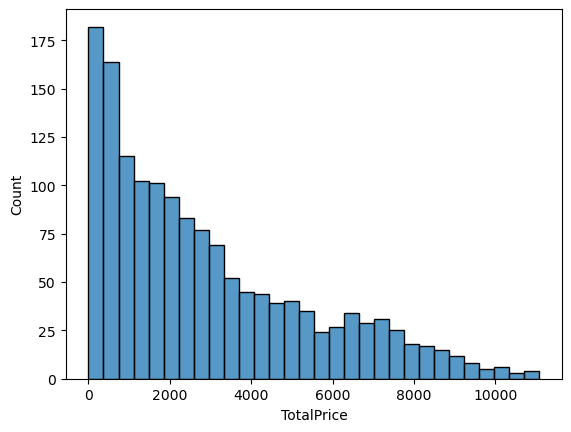

In [17]:
sns.histplot(
    df["TotalPrice"],
    bins=30
)

plt.show()

In [18]:
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

In [19]:
outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

print(outliers.shape)

(17, 19)


In [20]:
df["TotalPrice"] = np.clip(
    df["TotalPrice"],
    lower,
    upper
)

In [21]:
df["DeliveryDays"] = (
    df["DeliveryDate"] -
    df["OrderDate"]
).dt.days

In [22]:
df["NetRevenue"] = (
    df["TotalPrice"] -
    (df["TotalPrice"]*df["Discount"]/100)
)

In [23]:
df["PricePerItem"] = (
    df["TotalPrice"] /
    df["Quantity"]
)

In [24]:
df["HighValueOrder"] = np.where(
    df["TotalPrice"] > 1000,
    1,
    0
)

In [25]:
numeric_df = df.select_dtypes(
    include=np.number
)

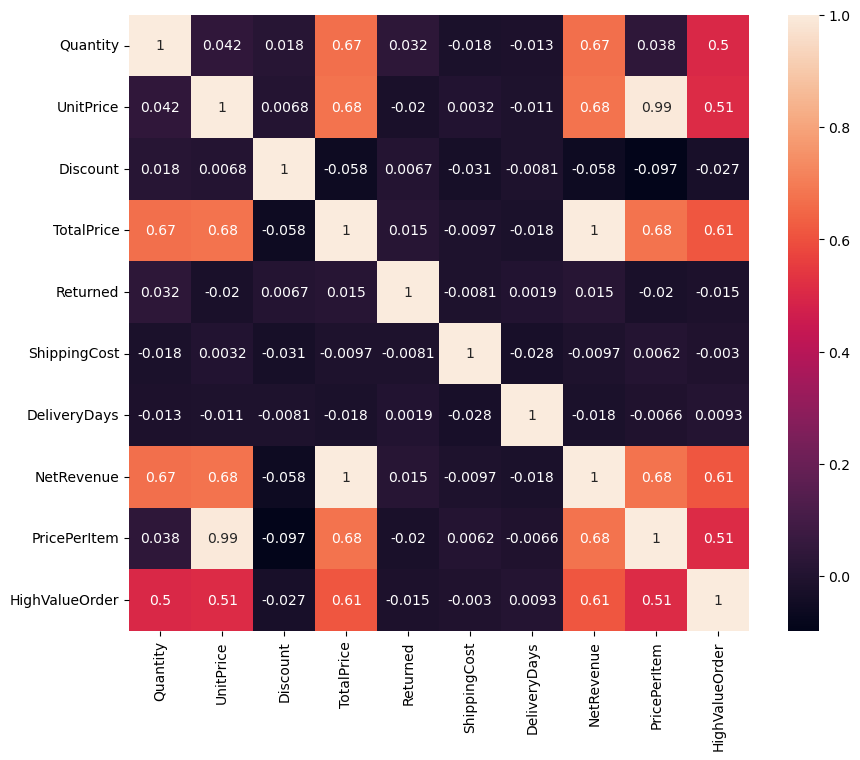

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [27]:
df.to_csv(
    "cleaned_data.csv",
    index=False
)